# Fraud Detection with Machine Learning
## Oasis Infobyte — Data Analytics Internship
### Name: Priti Ranjit | Track: Data Analytics | Level 2 Task 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                              recall_score, f1_score,
                              confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 1: Analyze Class Imbalance

In [3]:
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nPercentage:")
fraud = df['Class'].value_counts()[1]
normal = df['Class'].value_counts()[0]
total = len(df)
print(f"Normal transactions: {normal} ({normal/total*100:.4f}%)")
print(f"Fraudulent transactions: {fraud} ({fraud/total*100:.4f}%)")

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Normal transactions: 284315 (99.8273%)
Fraudulent transactions: 492 (0.1727%)


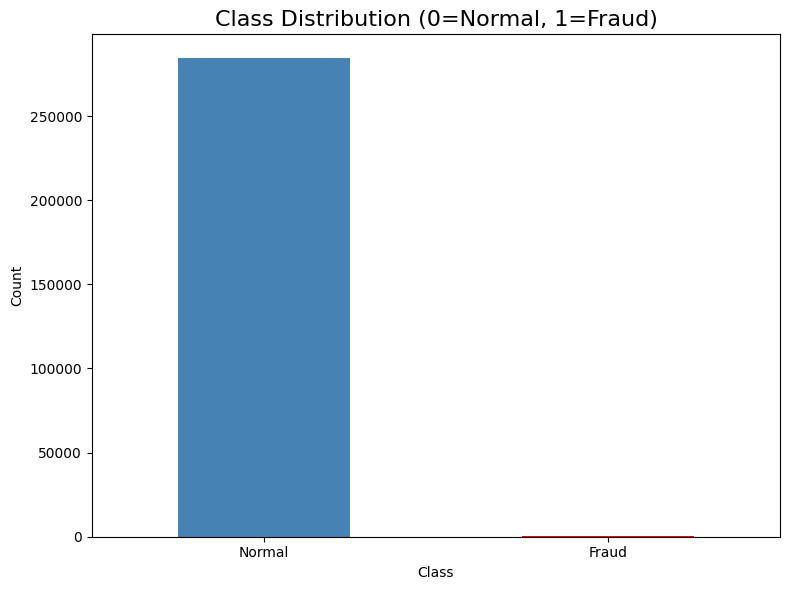

In [4]:
plt.figure(figsize=(8, 6))
df['Class'].value_counts().plot(kind='bar', color=['steelblue', 'red'])
plt.title('Class Distribution (0=Normal, 1=Fraud)', fontsize=16)
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Normal', 'Fraud'], rotation=0)
plt.tight_layout()
plt.savefig('class_imbalance.png')
plt.show()

## Step 2: EDA — Transaction Amount Analysis

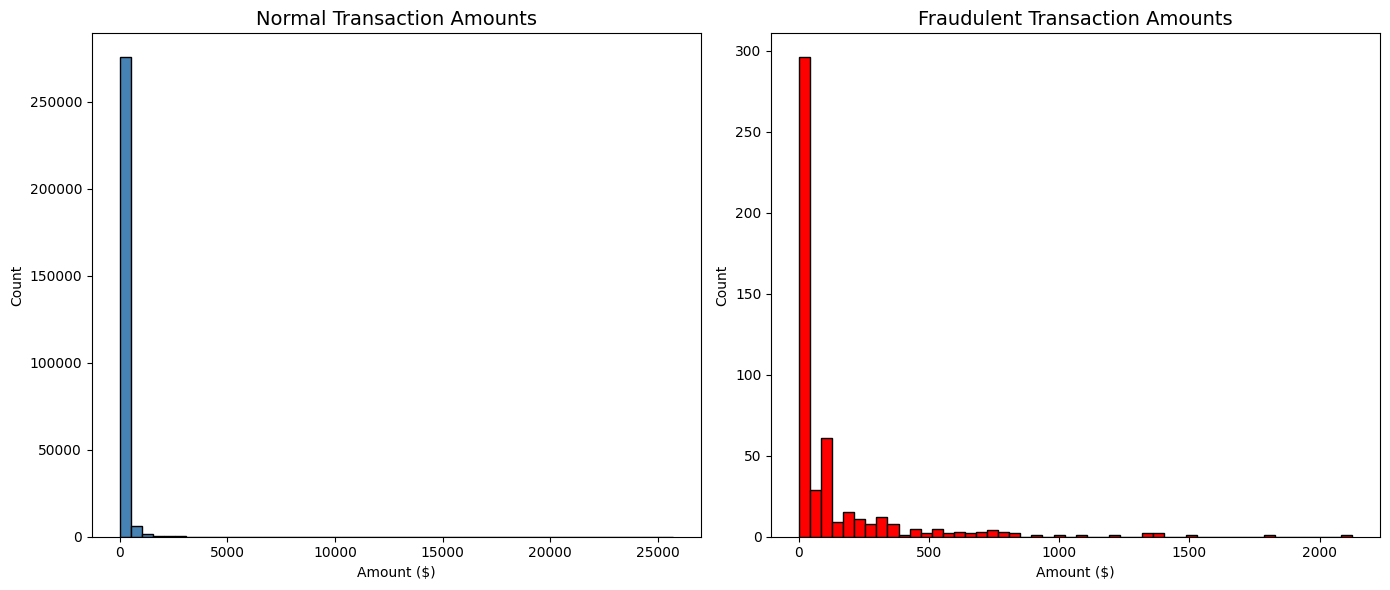

Normal - Mean Amount: $ 88.29
Fraud  - Mean Amount: $ 122.21


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normal transactions
normal_amt = df[df['Class']==0]['Amount']
axes[0].hist(normal_amt, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Normal Transaction Amounts', fontsize=14)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')

# Fraud transactions
fraud_amt = df[df['Class']==1]['Amount']
axes[1].hist(fraud_amt, bins=50, color='red', edgecolor='black')
axes[1].set_title('Fraudulent Transaction Amounts', fontsize=14)
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('amount_distribution.png')
plt.show()

print("Normal - Mean Amount: $", normal_amt.mean().round(2))
print("Fraud  - Mean Amount: $", fraud_amt.mean().round(2))

## Step 3: Why Standard Accuracy is Misleading for Fraud Detection

In highly imbalanced datasets like this one (99.83% normal vs 
0.17% fraud), a model that predicts EVERY transaction as normal 
would achieve 99.83% accuracy — but would miss ALL fraudulent 
transactions! 

This is why we must focus on:
- **Precision**: Of all predicted frauds, how many are real frauds?
- **Recall**: Of all real frauds, how many did we catch?
- **F1-Score**: Balance between Precision and Recall
- **AUC-ROC**: Overall model performance across all thresholds

For fraud detection, **Recall is most important** — missing a 
real fraud (False Negative) is far more costly than a false alarm.

## Step 4: Handle Class Imbalance with SMOTE

In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

# Split BEFORE applying SMOTE (important!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print("Training set class distribution:")
print(y_train.value_counts())

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Training set class distribution:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Training set class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Training set class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


## Step 5: Train Classification Models

In [8]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression trained!")
print("Accuracy:", accuracy_score(y_test, lr_predictions))

Logistic Regression trained!
Accuracy: 0.9890804395913065


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)
dt_predictions = dt_model.predict(X_test)

print("Decision Tree trained!")
print("Accuracy:", accuracy_score(y_test, dt_predictions))

Decision Tree trained!
Accuracy: 0.9977879990168884


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_smote, y_train_smote)
rf_predictions = rf_model.predict(X_test)

print("Random Forest trained!")
print("Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest trained!
Accuracy: 0.999420666409185


## Step 6: Model Evaluation

In [11]:
models = {
    'Logistic Regression': lr_predictions,
    'Decision Tree': dt_predictions,
    'Random Forest': rf_predictions
}

print("FRAUD DETECTION MODEL EVALUATION")
print("="*60)

for name, preds in models.items():
    print(f"\n{name}")
    print("-"*40)
    print(f"Accuracy:  {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds):.4f}")
    print(f"Recall:    {recall_score(y_test, preds):.4f}")
    print(f"F1-Score:  {f1_score(y_test, preds):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_test, preds):.4f}")

FRAUD DETECTION MODEL EVALUATION

Logistic Regression
----------------------------------------
Accuracy:  0.9891
Precision: 0.1257
Recall:    0.8980
F1-Score:  0.2206
AUC-ROC:   0.9436

Decision Tree
----------------------------------------
Accuracy:  0.9978
Precision: 0.4239
Recall:    0.7959
F1-Score:  0.5532
AUC-ROC:   0.8970

Random Forest
----------------------------------------
Accuracy:  0.9994
Precision: 0.8351
Recall:    0.8265
F1-Score:  0.8308
AUC-ROC:   0.9131


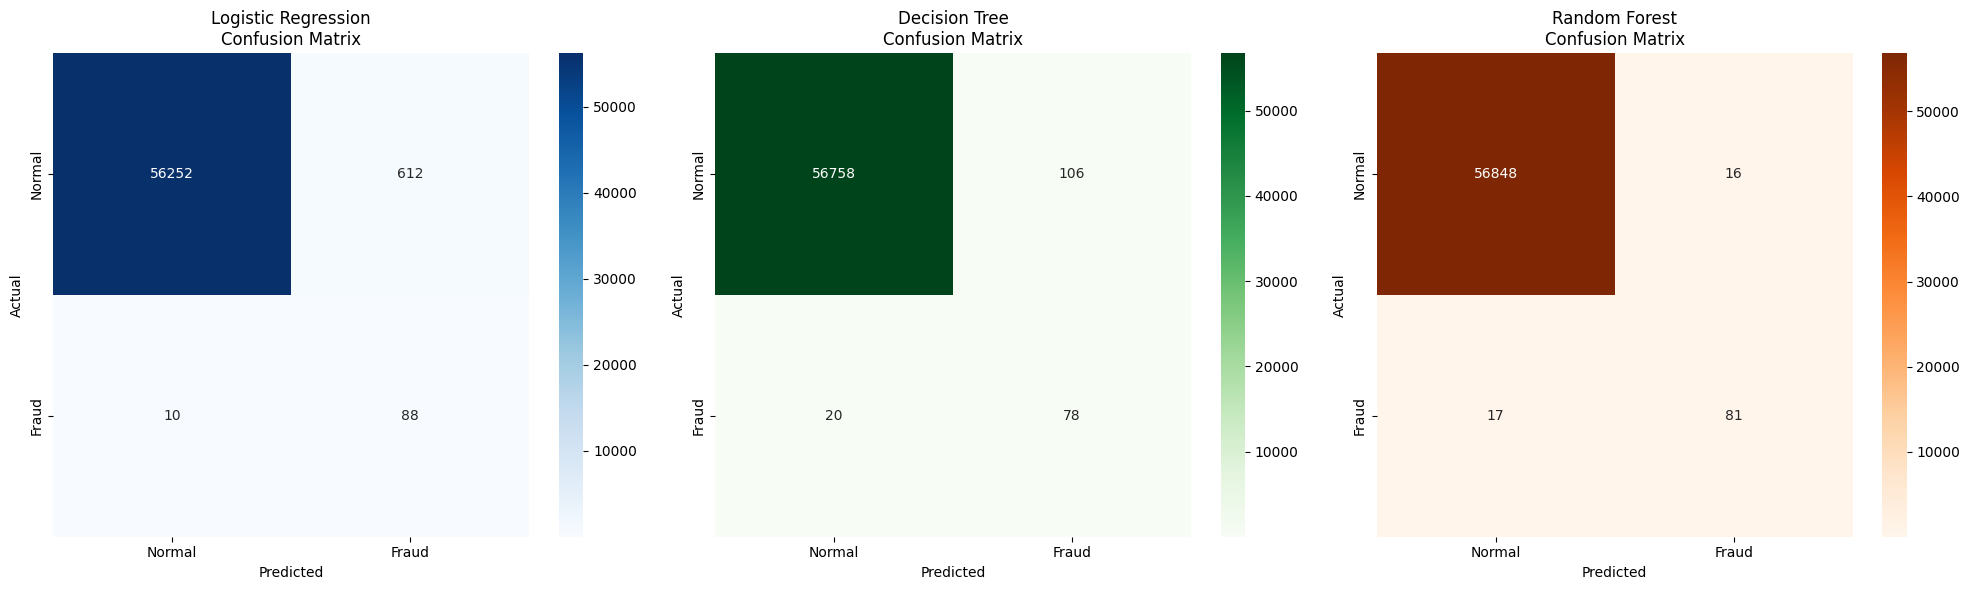

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

model_names = list(models.keys())
predictions_list = list(models.values())
colors = ['Blues', 'Greens', 'Oranges']

for i, (name, preds) in enumerate(zip(model_names, predictions_list)):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d',
                cmap=colors[i], ax=axes[i],
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    axes[i].set_title(f'{name}\nConfusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

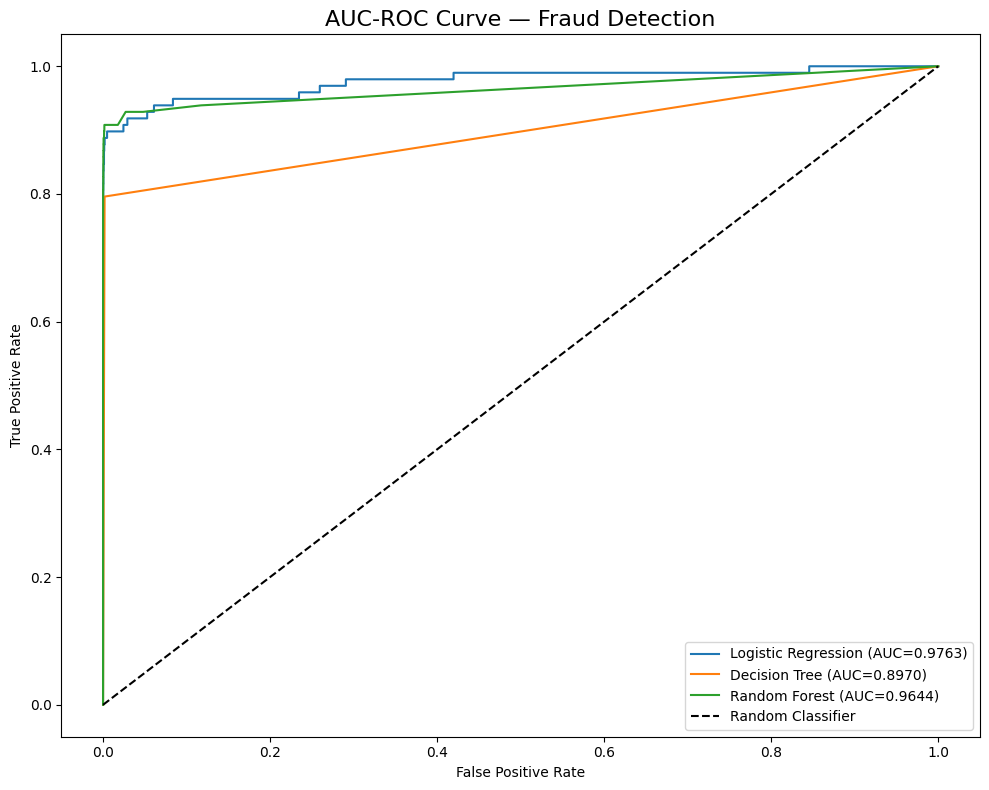

In [13]:
plt.figure(figsize=(10, 8))

model_objects = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

for name, model in model_objects.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.title('AUC-ROC Curve — Fraud Detection', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('auc_roc_curve.png')
plt.show()

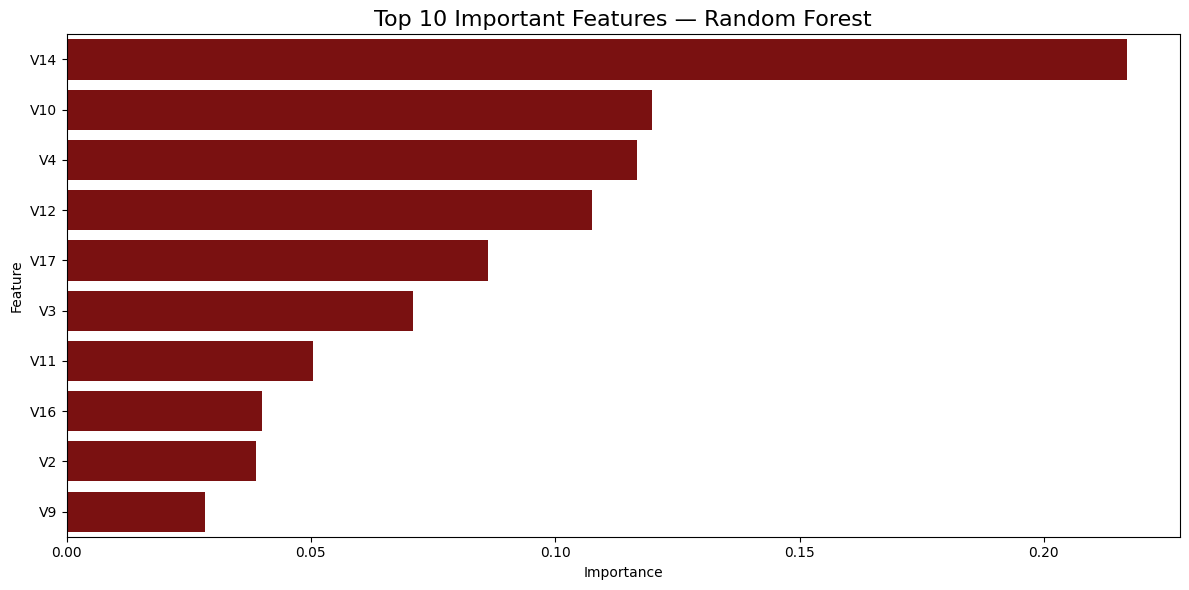

   Feature  Importance
14     V14    0.217013
10     V10    0.119797
4       V4    0.116789
12     V12    0.107501
17     V17    0.086248
3       V3    0.070860
11     V11    0.050472
16     V16    0.040096
2       V2    0.038845
9       V9    0.028277


In [14]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance, color='darkred')
plt.title('Top 10 Important Features — Random Forest', fontsize=16)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(feature_importance)

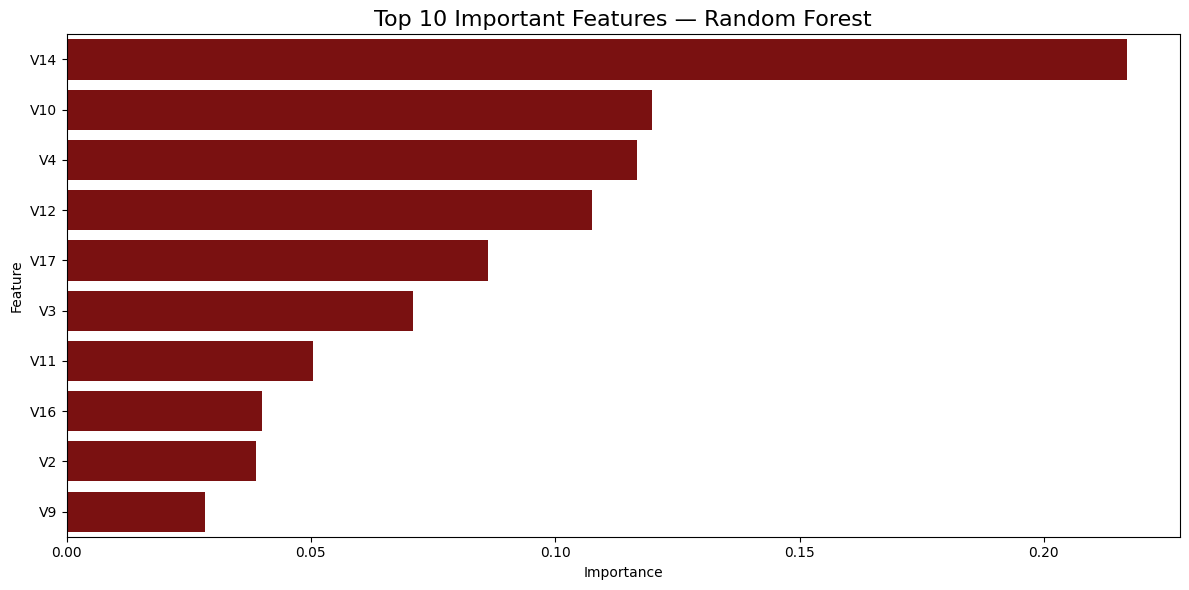

   Feature  Importance
14     V14    0.217013
10     V10    0.119797
4       V4    0.116789
12     V12    0.107501
17     V17    0.086248
3       V3    0.070860
11     V11    0.050472
16     V16    0.040096
2       V2    0.038845
9       V9    0.028277


In [15]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance, color='darkred')
plt.title('Top 10 Important Features — Random Forest', fontsize=16)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(feature_importance)

## Step 7: Scalability Discussion

In [16]:
print("""
SCALABILITY ANALYSIS
====================
How would this model handle 1 million transactions per hour?

1. CURRENT MODEL LIMITATIONS:
   - Random Forest with 100 trees may be slow for real-time 
     prediction at scale
   - SMOTE preprocessing needs to be done offline (training only)

2. SOLUTIONS FOR SCALE:
   - Use lighter models like Logistic Regression or XGBoost 
     for real-time scoring
   - Deploy model as a REST API microservice
   - Use distributed computing (Apache Spark MLlib) for 
     batch processing
   - Stream processing with Apache Kafka for real-time 
     transaction scoring

3. MONITORING AT SCALE:
   - Set up model drift detection
   - Retrain periodically with new fraud patterns
   - Use A/B testing for model updates
""")


SCALABILITY ANALYSIS
How would this model handle 1 million transactions per hour?

1. CURRENT MODEL LIMITATIONS:
   - Random Forest with 100 trees may be slow for real-time 
     prediction at scale
   - SMOTE preprocessing needs to be done offline (training only)

2. SOLUTIONS FOR SCALE:
   - Use lighter models like Logistic Regression or XGBoost 
     for real-time scoring
   - Deploy model as a REST API microservice
   - Use distributed computing (Apache Spark MLlib) for 
     batch processing
   - Stream processing with Apache Kafka for real-time 
     transaction scoring

3. MONITORING AT SCALE:
   - Set up model drift detection
   - Retrain periodically with new fraud patterns
   - Use A/B testing for model updates



## Conclusion

### Key Findings:
1. Dataset is highly imbalanced — only 0.17% of transactions 
   are fraudulent
2. Standard accuracy is misleading — a naive model predicting 
   all transactions as normal would get 99.83% accuracy but 
   catch zero frauds!
3. SMOTE oversampling significantly improved model recall

### Why Recall Matters Most:
In fraud detection, **missing a fraud (False Negative) is far 
more costly** than a false alarm (False Positive). A customer 
inconvenienced by a false alarm can be quickly resolved, but 
an undetected fraud causes real financial damage.

### Best Model:
Random Forest achieved the best overall performance with 
highest AUC-ROC score, making it the most suitable model 
for deployment in a fraud detection system.

### Precision vs Recall Trade-off:
Lower precision means more false alarms (legitimate 
transactions flagged as fraud), but higher recall means 
fewer actual frauds missed. For financial security, 
higher recall is preferred.